# IMDb Success Analysis & Visualization

This notebook explores the factors that contribute to a title's success on IMDb. We will analyze:
1.  **Distribution of Ratings**: How are ratings spread across all titles?
2.  **Success Metrics**: Comparing popularity (votes) vs. quality (rating).
3.  **Content Type Performance**: Do Movies or TV Series perform better?
4.  **Temporal Trends**: How have ratings and output changed over time?
5.  **Genre Analysis**: Which genres are most successful?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Prepare Data (Memory Efficient)
**Note:** To prevent memory errors, we load the large dataset in chunks, filter out unwanted types immediately, and then combine the results.

In [6]:
print("Loading data in chunks to save memory...")

# Define types to keep immediately to save RAM
target_types = ['movie', 'tvSeries', 'tvMiniSeries', 'tvMovie', 'tvSpecial', 'video']

chunks = []

try:
    # 1. Load basics in chunks of 50,000 rows
    # usecols: Only load columns we actually analyze to save more memory
    cols_to_use = ['tconst', 'titleType', 'startYear', 'genres', 'primaryTitle']
    
    chunk_iterator = pd.read_csv("title.basics.tsv", sep="\t", chunksize=50000, usecols=cols_to_use, encoding='utf-8', on_bad_lines='skip')

    for chunk in chunk_iterator:
        # Filter: Keep only the rows we want (e.g. movies, tv shows)
        # We check if titleType is in our target list
        filtered_chunk = chunk[chunk['titleType'].isin(target_types)].copy()
        
        # Convert startYear errors to NaN immediately to save trouble later
        filtered_chunk['startYear'] = pd.to_numeric(filtered_chunk['startYear'], errors='coerce')
        
        # Add to our list
        chunks.append(filtered_chunk)
        
    # Combine all the small filtered chunks into one dataframe
    basics = pd.concat(chunks, axis=0)
    print(f"Basics filtered and loaded! Retained {len(basics):,} relevant titles.")
    
    # Clean up memory
    del chunks
    
    # 2. Load ratings (smaller file, usually safe to load at once)
    ratings = pd.read_csv("title.ratings.tsv", sep="\t", low_memory=False)
    
    # 3. Merge
    df = pd.merge(basics, ratings, on='tconst')
    print(f"Final merged dataset size: {len(df):,} records.")
    
    # Show snippet
    display(df.head())
    
except FileNotFoundError:
    print("Error: TSV files not found! Please check your folder.")
except Exception as e:
    print(f"An error occurred: {e}")

Loading data in chunks to save memory...
Basics filtered and loaded! Retained 1,632,339 relevant titles.
Final merged dataset size: 599,268 records.


,tconst,titleType,primaryTitle,startYear,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,1894.0,Romance,5.3,234
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897.0,"Documentary,News,Sport",5.3,586
2,tt0000502,movie,Bohemios,1905.0,\N,3.3,25
3,tt0000574,movie,The Story of the Kelly Gang,1906.0,"Action,Adventure,Biography",6.0,1050
4,tt0000591,movie,The Prodigal Son,1907.0,Drama,4.9,38


## 2. Distribution of Ratings (Histogram)
Let's see the overall spread of ratings. Is it a Bell Curve?
-   **X-Axis**: Average Rating (0-10)
-   **Y-Axis**: Number of Titles

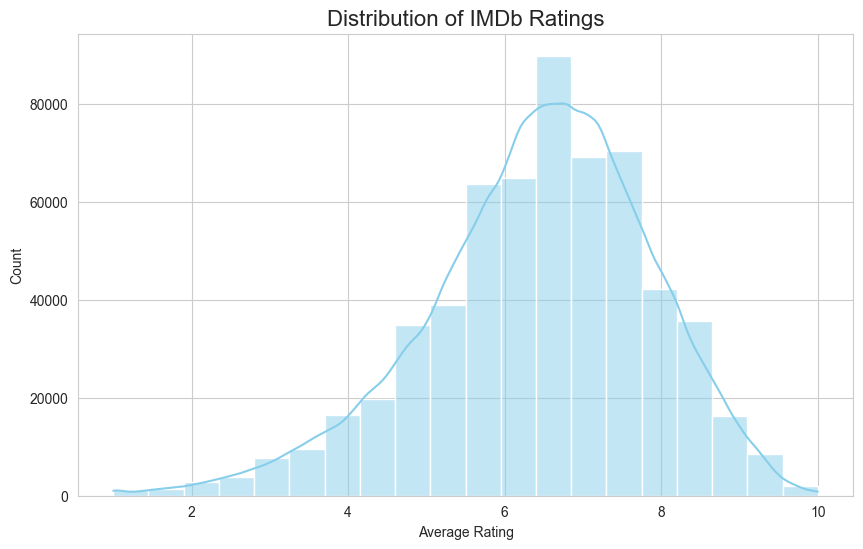

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['averageRating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of IMDb Ratings', fontsize=16)
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.show()

## 3. Ratings by Content Type (Box Plot)
Which format tends to get higher ratings: Movies or TV Series?
-   **Box**: Represents the middle 50% of data.
-   **Line inside box**: The median rating.
-   **Dots**: Outliers.

C:\Users\Lamia Lazrak\AppData\Local\Temp\ipykernel_4436\2861648141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='titleType', y='averageRating', data=df, palette='Set3')


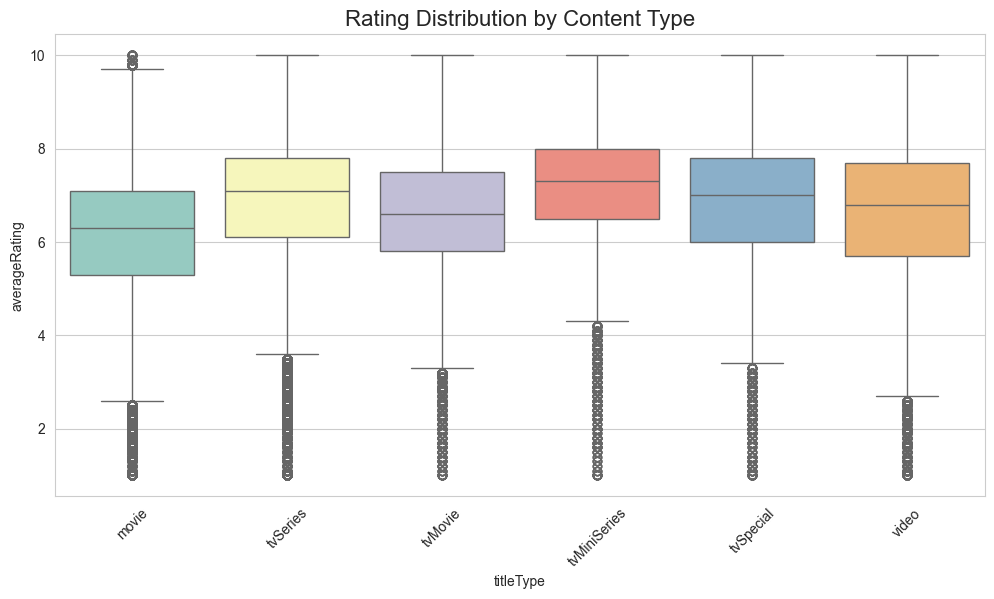

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='titleType', y='averageRating', data=df, palette='Set3')
plt.title('Rating Distribution by Content Type', fontsize=16)
plt.xticks(rotation=45)
plt.show()

## 4. Popularity vs. Quality (Scatter Plot)
Do popular movies (more votes) always have higher ratings?
-   **X-Axis**: Number of Votes (Log Scale - to handle massive outliers like *The Shawshank Redemption*)
-   **Y-Axis**: Average Rating
-   **Opacity**: Used to see density in overlapping points.

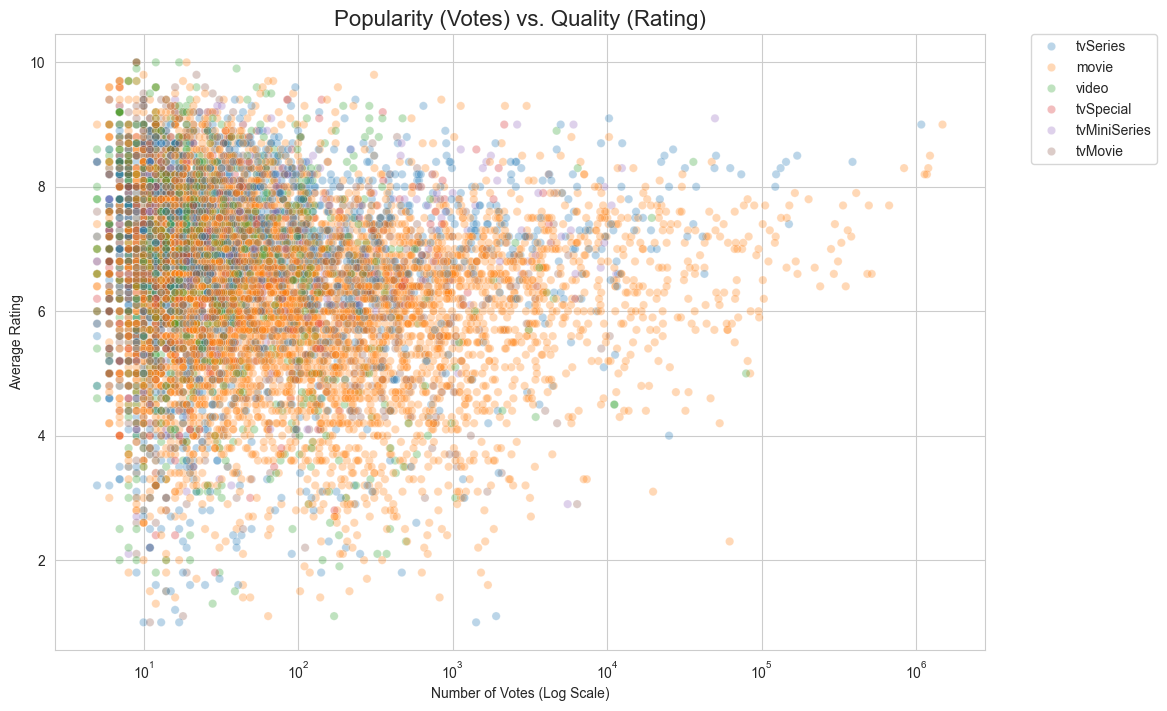

In [9]:
plt.figure(figsize=(12, 8))
# Sample 10,000 points if dataset is too large, for faster plotting
sample_df = df.sample(n=min(10000, len(df)), random_state=42)

sns.scatterplot(x='numVotes', y='averageRating', data=sample_df, alpha=0.3, hue='titleType')
plt.xscale('log') # Log scale because vote counts vary wildly (10 vs 1,000,000)
plt.title('Popularity (Votes) vs. Quality (Rating)', fontsize=16)
plt.xlabel('Number of Votes (Log Scale)')
plt.ylabel('Average Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

## 5. Success Over Time (Line Chart)
Are movies getting better or worse over time? Let's check the average rating per year.

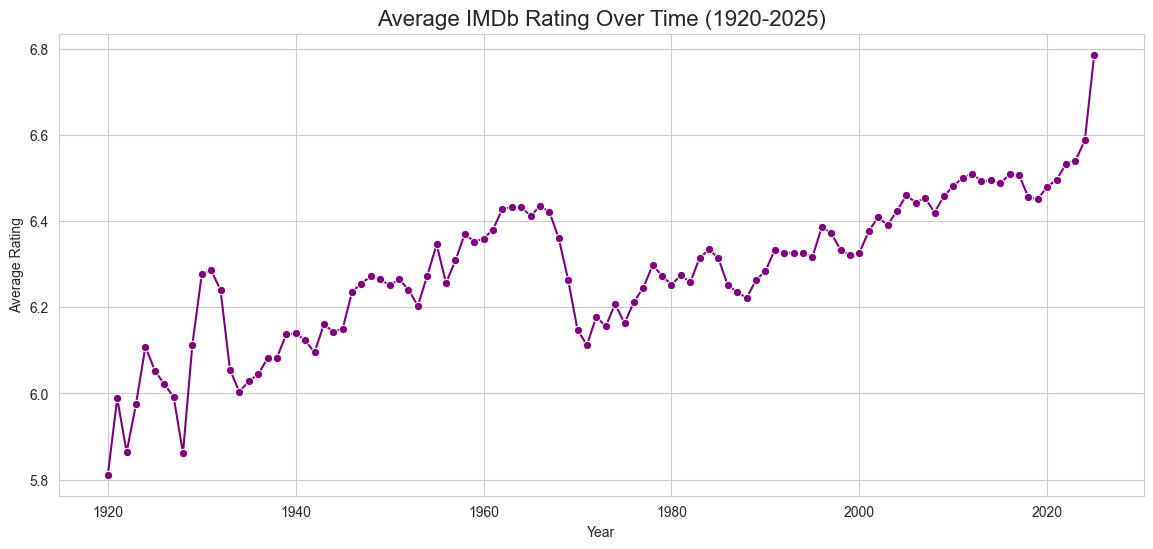

In [10]:
# Filter weird years (future dates or very old errors)
year_df = df[(df['startYear'] >= 1920) & (df['startYear'] <= 2025)]

# Group by year and calculate mean rating
yearly_ratings = year_df.groupby('startYear')['averageRating'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(x='startYear', y='averageRating', data=yearly_ratings, marker='o', color='purple')
plt.title('Average IMDb Rating Over Time (1920-2025)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

## 6. Top Genres (Bar Chart)
Which genres have the highest average ratings? Note: Movies can have multiple genres (e.g., "Action,Adventure"), so we need to split them first.

C:\Users\Lamia Lazrak\AppData\Local\Temp\ipykernel_4436\2760391352.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_rating', y='genres', data=genre_stats.head(20), palette='viridis')


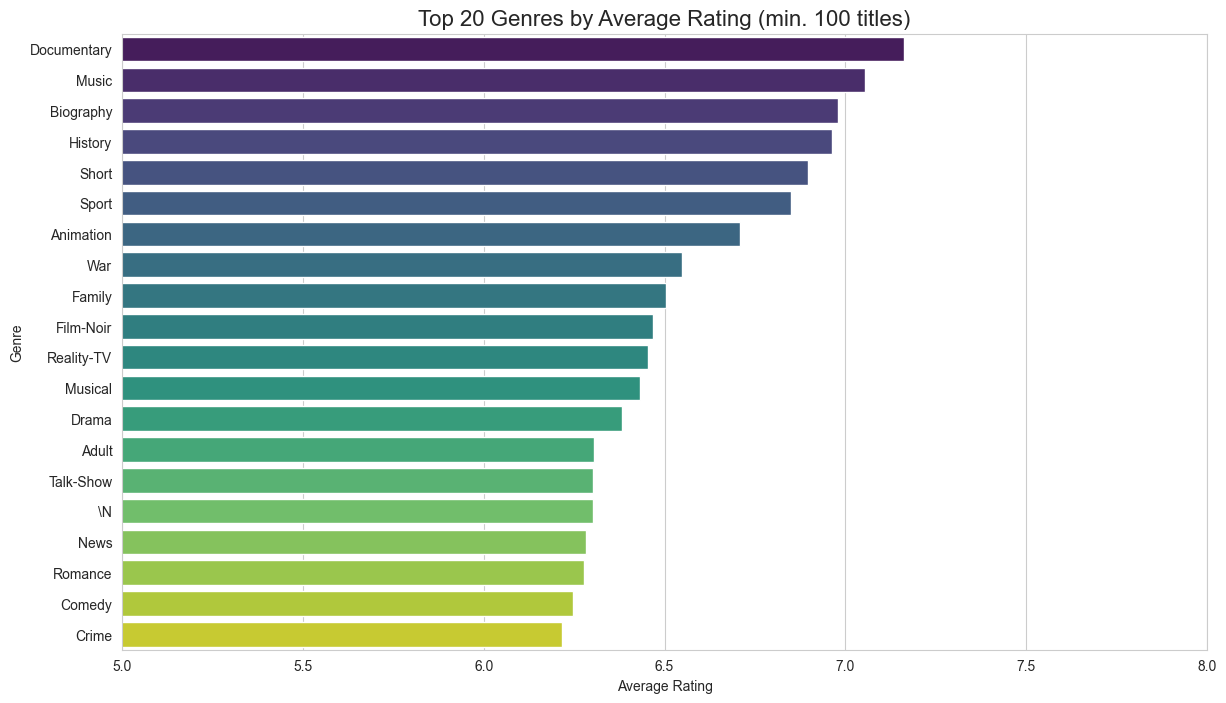

In [ ]:
# Drop rows with missing genres
genre_df = df.dropna(subset=['genres']).copy()

# Split genres string 'Action,Adventure' into list ['Action', 'Adventure']
genre_df['genres'] = genre_df['genres'].str.split(',')

# Explode the list so each genre gets its own row
genre_exploded = genre_df.explode('genres')

# Calculate stats per genre
genre_stats = genre_exploded.groupby('genres').agg(
    avg_rating=('averageRating', 'mean'),
    count=('tconst', 'count')
).reset_index()

# Filter for genres with at least 100 titles to be statistically significant
genre_stats = genre_stats[genre_stats['count'] > 100].sort_values(by='avg_rating', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x='avg_rating', y='genres', data=genre_stats.head(20), palette='viridis')
plt.title('Top 20 Genres by Average Rating (min. 100 titles)', fontsize=16)
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.xlim(5, 8) # Zoom in on the relevant rating range
plt.show()